In [13]:
# download
from langgraph.graph import StateGraph, START, END
from typing import TypedDict

In [14]:
"""
Task: BMI Calculator
Input: weight (in kg), height (in meters)
Output: BMI value

"""

'\nTask: BMI Calculator\nInput: weight (in kg), height (in meters)\nOutput: BMI value\n\n'

In [ ]:
class BMI(TypedDict):
    weight: float # in kilograms
    height: float # in meters
    bmi: float
    category: str

In [16]:
# define your graph
state_graph = StateGraph(BMI)


# define your nodes

# 1.) Calculate BMI Node
def calculateBMI(state: BMI) -> BMI:
    weight = state["weight"]
    height = state["height"]
    bmi = weight / (height ** 2)
    state["bmi"] = bmi
    return state


def categorizeBMI(state: BMI) -> BMI:
    bmi = state["bmi"]
    if bmi < 18.5:
        category = "Underweight"
    elif 18.5 <= bmi < 24.9:
        category = "Normal weight"
    elif 25 <= bmi < 29.9:
        category = "Overweight"
    else:
        category = "Obesity"
    state["category"] = category
    return state

In [17]:
# Add nodes and edges to the graph
state_graph.add_node("bmi", calculateBMI)
state_graph.add_node("category", categorizeBMI)

state_graph.add_edge(START, "bmi")
state_graph.add_edge("bmi", "category")
state_graph.add_edge("category", END)




In [20]:
# compile and invoke the graph

workflow = state_graph.compile()

initialState = {"weight": 70, "height": 1.75}

finalState = workflow.invoke(initialState)

print(f"Final State: {finalState}")

Final State: {'weight': 70, 'height': 1.75, 'bmi': 22.857142857142858, 'category': 'Normal weight'}


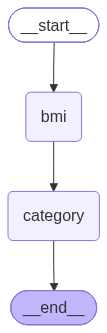

In [ ]:
# Display the graph

from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())
